# E‑Commerce Review Intelligence 



Customer reviews are unstructured text, but they encode repeatable product themes: **quality**, **fit**, **style**, and **comfort**. 

This notebook turns raw review text into **semantic vectors** using OpenAI embeddings, explores structure with **t‑SNE**, assigns **prototype‑based topic labels** via cosine geometry, and demonstrates **similar‑review retrieval** with **Chroma** (persistent vector storage).
We are using text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.



## Tech stack

| Layer | Choice |
|------|--------|
| Language | Python 3 |
| Embeddings | OpenAI `text-embedding-3-small` |
| ML / numerics | `numpy`, `scikit-learn`, `scipy` |
| Visualization | `matplotlib` |
| Vector store | `chromadb` (persistent client) |



### What this notebook shows

- **Embeddings turn text into geometry.** Each review becomes a high-dimensional vector so that *semantically similar* comments sit closer together in space than unrelated ones. That is why **t-SNE** can reveal clusters or bands in the scatter plot: they are groups of reviews that *tend to be about similar things*, even when wording differs.
- **Prototype labels make themes explicit.** Mapping every review to the nearest of *Quality / Fit / Style / Comfort* is a simple, interpretable way to summarize "what people are talking about" without hand-labeling thousands of rows.
- **Vector search operationalizes similarity.** Chroma (or any vector DB) lets you move from a one-off notebook to **retrieval**: given a new sentence - support ticket, survey response, product note person can surface the **closest historical reviews** quickly.


### Environment & dependencies




In [14]:
# %pip install -q "chromadb>=1.0.0" "openai>=1.0.0" pandas numpy scipy scikit-learn matplostlib python-dotenv

from importlib.metadata import PackageNotFoundError, version


def ensure(pkg: str, spec: str | None = None) -> None:
    # Install *pkg* if missing; optionally pass a pip requirement spec.
    try:
        version(pkg)
    except PackageNotFoundError:
        import sys, subprocess

        cmd = [sys.executable, "-m", "pip", "install", spec or pkg]
        subprocess.check_call(cmd)


ensure("chromadb", "chromadb>=1.0.0")
ensure("openai")
ensure("pandas")
ensure("numpy")
ensure("scipy")
ensure("matplotlib")
ensure("python-dotenv")

### Configuration & data ingestion

We resolve the Kaggle **Women's E‑Commerce Clothing Reviews** CSV in a portable way: check common local filenames, then fall back to a known sample path if you keep one on your machine. Only rows with non‑empty `Review Text` are used so embedding calls stay clean.


In [ ]:
from __future__ import annotations

from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv

load_dotenv()

reviews = pd.read_csv("retail_reviews_data.csv")
review_texts = reviews["Review Text"].dropna().astype(str)


print(f"Reviews with text: {len(review_texts):,}")
reviews.head()

Using data file: /Users/Afag/Desktop/retail_reviews_data.csv
Reviews with text: 958


,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Exploratory Data Analysis

Before embedding, we inspect the raw data to understand volume, shape, and distribution. Good EDA prevents surprises downstream and makes the NLP results interpretable.

In [16]:
# ── EDA setup — runs immediately after data is loaded ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

df_eda = pd.read_csv(DATA_PATH)
df_eda["review_len"] = df_eda["Review Text"].fillna("").str.len()
df_eda["Sentiment"] = df_eda["Rating"].apply(
    lambda r: "Positive" if r >= 4 else ("Negative" if r <= 2 else "Neutral")
)

print(f"Total reviews       : {len(df_eda):,}")
print(f"Reviews with text   : {df_eda['Review Text'].notna().sum():,}")
print(f"Unique products     : {df_eda['Clothing ID'].nunique():,}")
print(f"Departments         : {df_eda['Department Name'].nunique()}")
print(f"Recommended rate    : {df_eda['Recommended IND'].mean()*100:.1f}%")
print(f"Average rating      : {df_eda['Rating'].mean():.2f} / 5")
df_eda.head()

Total reviews       : 1,000
Reviews with text   : 958
Unique products     : 149
Departments         : 6
Recommended rate    : 81.8%
Average rating      : 4.19 / 5


,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,review_len,Sentiment
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,53,Positive
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,303,Positive
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,500,Neutral
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,124,Positive
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,192,Positive


#### Distribution plots

Four panels: rating counts, review length, top departments by volume, and average rating per department.

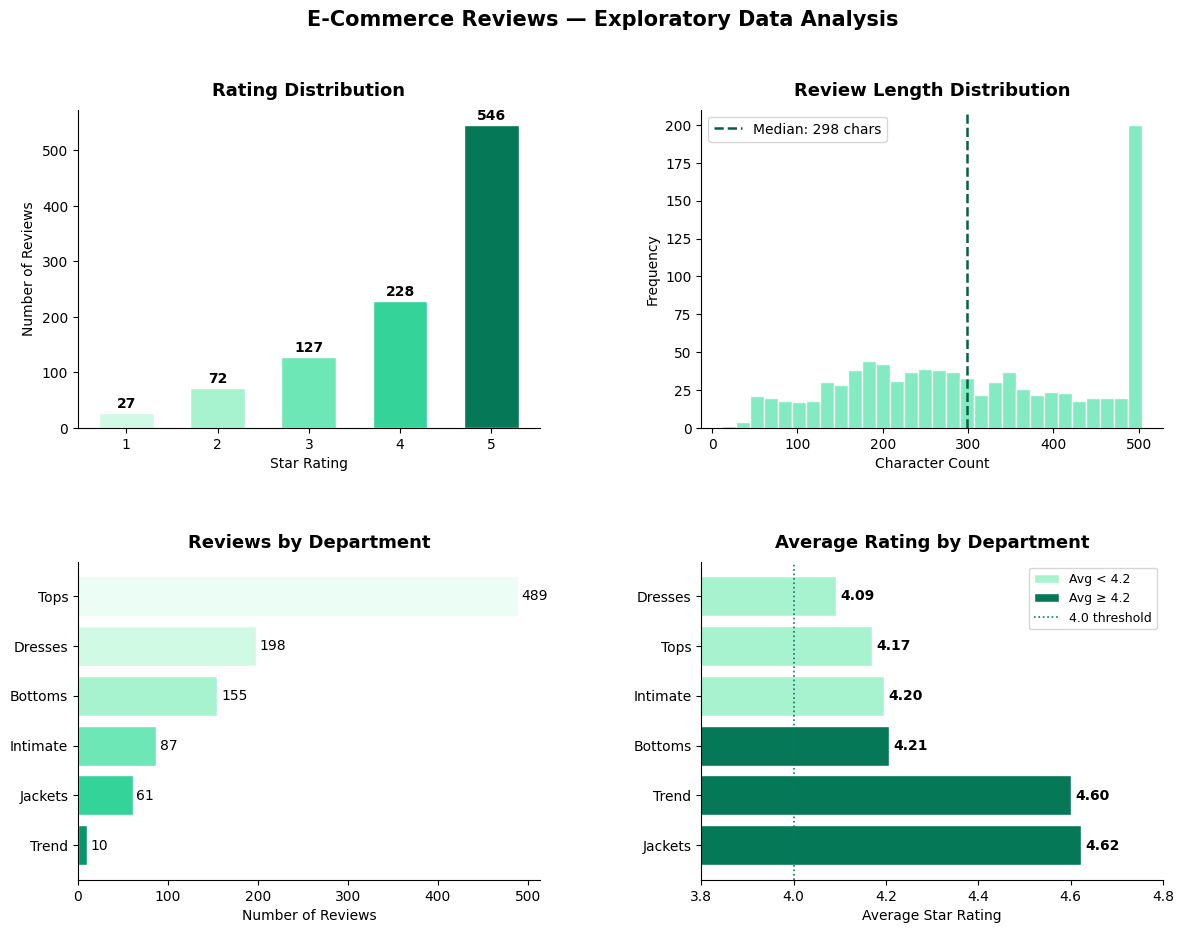

Key insight: 54.6% of reviews are 5-star; Jackets and Trend departments have the highest satisfaction.


In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# 1. Rating distribution
ax1 = fig.add_subplot(gs[0, 0])
rating_counts = df_eda["Rating"].value_counts().sort_index()
# Cohesive green family (sequential light → dark for 1–5 stars)
colors_rating = ["#d1fae5", "#a7f3d0", "#6ee7b7", "#34d399", "#047857"]
bars = ax1.bar(
    rating_counts.index,
    rating_counts.values,
    color=colors_rating,
    edgecolor="white",
    width=0.6,
)
ax1.set_title("Rating Distribution", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("Star Rating")
ax1.set_ylabel("Number of Reviews")
ax1.set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars, rating_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        str(val),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax1.spines[["top", "right"]].set_visible(False)

# 2. Review length histogram
ax2 = fig.add_subplot(gs[0, 1])
lengths = df_eda[df_eda["review_len"] > 0]["review_len"]
ax2.hist(lengths, bins=30, color="#6ee7b7", edgecolor="white", alpha=0.85)
ax2.axvline(
    lengths.median(),
    color="#065f46",
    linestyle="--",
    linewidth=1.8,
    label=f"Median: {int(lengths.median())} chars",
)
ax2.set_title("Review Length Distribution", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("Character Count")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

# 3. Reviews by department
ax3 = fig.add_subplot(gs[1, 0])
dept_counts = df_eda["Department Name"].value_counts()
palette = ["#ecfdf5", "#d1fae5", "#a7f3d0", "#6ee7b7", "#34d399", "#059669"]
bars3 = ax3.barh(
    dept_counts.index,
    dept_counts.values,
    color=palette[: len(dept_counts)],
    edgecolor="white",
)
ax3.set_title("Reviews by Department", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("Number of Reviews")
for bar, val in zip(bars3, dept_counts.values):
    ax3.text(
        bar.get_width() + 4,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax3.spines[["top", "right"]].set_visible(False)
ax3.invert_yaxis()

# 4. Avg rating per department
ax4 = fig.add_subplot(gs[1, 1])
avg_rating = df_eda.groupby("Department Name")["Rating"].mean().sort_values()
# Below vs above threshold: lighter vs deeper green (same hue family)
colors4 = ["#a7f3d0" if v < 4.2 else "#047857" for v in avg_rating.values]
bars4 = ax4.barh(avg_rating.index, avg_rating.values, color=colors4, edgecolor="white")
ax4.axvline(4.0, color="#0f766e", linestyle=":", linewidth=1.2)
ax4.set_title("Average Rating by Department", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("Average Star Rating")
ax4.set_xlim(3.8, 4.8)
for bar, val in zip(bars4, avg_rating.values):
    ax4.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
ax4.legend(
    handles=[
        Patch(facecolor="#a7f3d0", edgecolor="white", label="Avg < 4.2"),
        Patch(facecolor="#047857", edgecolor="white", label="Avg ≥ 4.2"),
        Line2D(
            [0],
            [0],
            color="#0f766e",
            linestyle=":",
            linewidth=1.2,
            label="4.0 threshold",
        ),
    ],
    fontsize=9,
)
ax4.spines[["top", "right"]].set_visible(False)
ax4.invert_yaxis()

plt.suptitle(
    "E-Commerce Reviews — Exploratory Data Analysis", fontsize=15, fontweight="bold"
)
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    "Key insight: 54.6% of reviews are 5-star; Jackets and Trend departments have the highest satisfaction."
)

#### Sentiment labels

We derive a three-class **Sentiment** variable directly from star ratings
- **Positive** = 4–5 stars
- **Neutral** = 3 stars
- **Negative** = 1–2 stars

This label is reused later to color t-SNE plots and power the summary table.

In [18]:
reviews_df = df_eda.copy()

sentiment_counts = reviews_df["Sentiment"].value_counts()
print("Sentiment breakdown:")
print(sentiment_counts.to_string())
print(f"\nPositive rate: {sentiment_counts['Positive'] / len(reviews_df) * 100:.1f}%")

Sentiment breakdown:
Sentiment
Positive    774
Neutral     127
Negative     99

Positive rate: 77.4%


### Imports

Core libraries for **API access**, **numerical work**, **geometry** (cosine distance), **t‑SNE**, **plotting**, and **Chroma's OpenAI embedding helper** for *query‑time* encoding (we store precomputed vectors at ingest time to avoid duplicate embedding work).


In [19]:
import numpy as np
import openai
from scipy.spatial import distance
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import chromadb
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

EMBEDDING_MODEL = "text-embedding-3-small"

if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError(
        "OPENAI_API_KEY is not set. Add it to your environment or a local .env file."
    )

openai_client = openai.OpenAI()

### Embedding pipeline (OpenAI)

OpenAI embeddings endpoints are safest when you **batch** inputs. Here we embed every cleaned review string and keep vectors aligned with the dataframe order.


In [20]:
def embed_texts_batched(
    texts: list[str],
    *,
    model: str = EMBEDDING_MODEL,
    batch_size: int = 128,
) -> list[list[float]]:
    out: list[list[float]] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        resp = openai_client.embeddings.create(model=model, input=batch)
        out.extend([row.embedding for row in resp.data])
    return out


texts = review_texts.tolist()
embeddings = embed_texts_batched(texts)
len(embeddings), len(texts)

(958, 958)

### Dimensionality reduction (t‑SNE)

t‑SNE is non‑linear and preserves **local neighborhoods**; it is excellent for *visual* clustering checks on embedding spaces. For large corpora, runtime grows quickly—here the dataset is modest, but the helper remains reusable.


In [21]:
def apply_tsne(
    emb: np.ndarray, *, perplexity: float = 30.0, learning_rate: str | float = "auto"
) -> np.ndarray:
    n = emb.shape[0]
    perp = float(min(perplexity, max(5.0, (n - 1) / 3)))
    tsne = TSNE(
        n_components=2,
        init="pca",
        learning_rate=learning_rate,
        perplexity=perp,
        random_state=0,
    )
    return tsne.fit_transform(emb)


embeddings_2d = apply_tsne(np.array(embeddings, dtype=np.float32))
embeddings_2d.shape

/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/Afag/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/Afag/miniforge3/lib/python3.1

(958, 2)

### Inspecting shapes

High‑dimensional embeddings are long vectors; t‑SNE maps each review to **2D coordinates** while preserving the **row count**.


In [22]:
original_shape = np.asarray(embeddings).shape
first_embedding = np.asarray(embeddings[0])[:10]
tsne_shape = embeddings_2d.shape
first_embedding_2d = embeddings_2d[0]

original_shape, first_embedding, tsne_shape, first_embedding_2d

((958, 1536),
 array([ 0.02560425, -0.04983521, -0.08630371,  0.01065063,  0.01544189,
        -0.04803467, -0.02523804,  0.04324341,  0.04364014, -0.02232361]),
 (958, 2),
 array([-20.87875 ,   9.626337], dtype=float32))

### Semantic prototypes + vector retrieval

1. **Prototype topics**: embed short topic names and assign each review to the **closest** prototype using **cosine distance** (smaller is closer).  
2. **Chroma**: persist vectors under `.chroma_portfolio/` for a minimal local “production‑ish” workflow.  
3. **Important API detail**: use separate handles for **OpenAI** vs **Chroma** so you do not accidentally shadow clients.

At ingest time we pass **precomputed embeddings** so Chroma does not re‑embed documents. Queries still use the collection embedding function to embed the *query string*.


In [24]:
categories = ["Quality", "Fit", "Style", "Comfort"]

cat_resp = openai_client.embeddings.create(model=EMBEDDING_MODEL, input=categories)
category_embeddings = [row.embedding for row in cat_resp.data]


def categorize_feedback(
    text_embedding: list[float], cat_embs: list[list[float]]
) -> str:
    similarities = [
        {"distance": distance.cosine(text_embedding, cat_emb), "index": i}
        for i, cat_emb in enumerate(cat_embs)
    ]
    # Pick the smallest *distance*, not the smallest *index*.
    closest = min(similarities, key=lambda x: x["distance"])
    return categories[closest["index"]]


feedback_categories = [categorize_feedback(e, category_embeddings) for e in embeddings]

CHROMA_DIR = str(Path.cwd() / ".chroma_portfolio")
Path(CHROMA_DIR).mkdir(parents=True, exist_ok=True)

chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)

COLLECTION = "review_embeddings"
try:
    chroma_client.delete_collection(COLLECTION)
except Exception:
    pass

embedding_fn = OpenAIEmbeddingFunction(
    model_name=EMBEDDING_MODEL,
    api_key=os.environ["OPENAI_API_KEY"],
)

review_embeddings_db = chroma_client.create_collection(
    name=COLLECTION,
    embedding_function=embedding_fn,
)

review_embeddings_db.add(
    documents=texts,
    ids=[str(i) for i in range(len(texts))],
    embeddings=embeddings,
)


def find_similar_reviews(input_text: str, *, n: int = 3) -> list[str]:
    collection = chroma_client.get_collection(
        name=COLLECTION,
        embedding_function=embedding_fn,
    )
    results = collection.query(query_texts=[input_text], n_results=n)
    return results["documents"][0]


example_review = "Absolutely wonderful - silky and sexy and comfortable"
most_similar_reviews = find_similar_reviews(example_review, n=3)
print(most_similar_reviews)

chroma_client.delete_collection(COLLECTION)

['Absolutely wonderful - silky and sexy and comfortable', 'Very comfortable and versatile. got lots of compliments.', 'This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.']


### Colored t-SNE projections



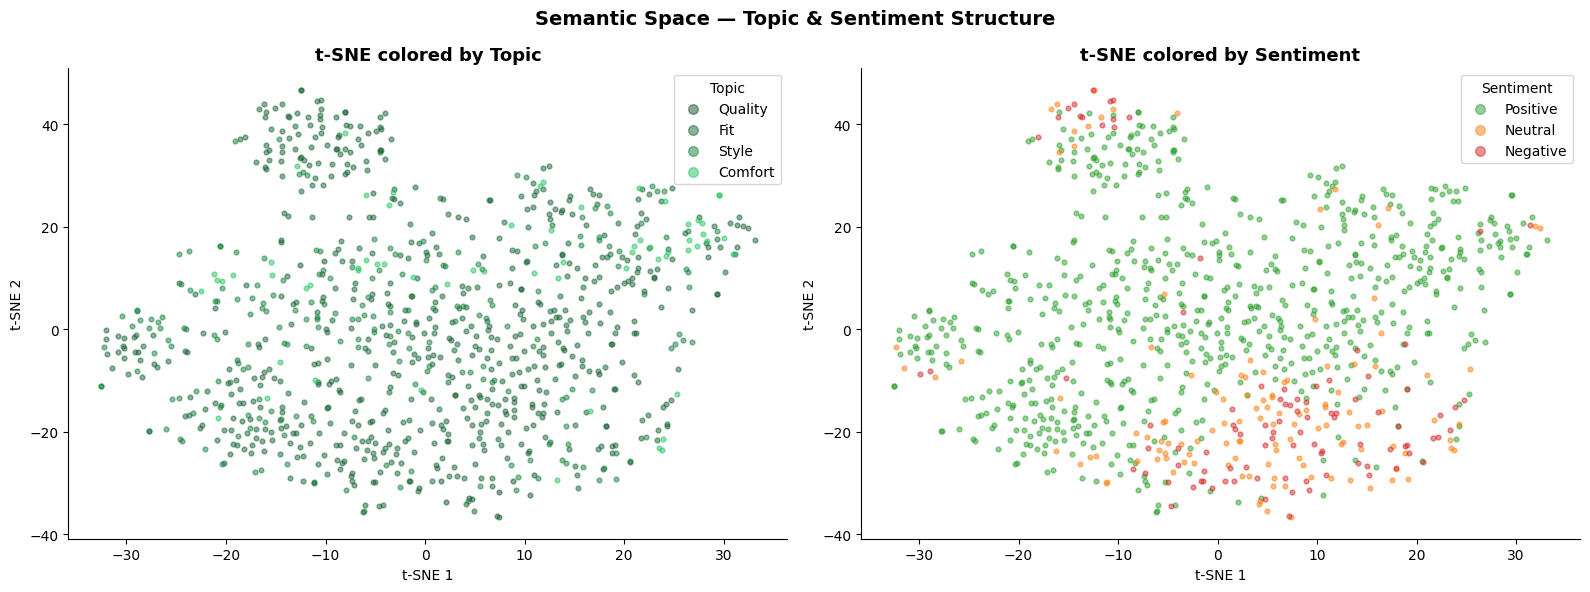

Observation: Negative reviews appear scattered across all topic clusters,
suggesting dissatisfaction is not isolated to one product dimension.


In [25]:
# Build aligned dataframe — runs after feedback_categories and embeddings_2d exist
aligned_df = reviews_df.dropna(subset=["Review Text"]).copy().reset_index(drop=True)
aligned_df["topic"] = feedback_categories
aligned_df["tsne_x"] = embeddings_2d[:, 0]
aligned_df["tsne_y"] = embeddings_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: by topic
# Related greens (one hue family — matches BI summary charts)
topic_palette = {
    "Quality": "#14532d",
    "Fit": "#166534",
    "Style": "#15803d",
    "Comfort": "#22c55e",
}
for topic, color in topic_palette.items():
    mask = aligned_df["topic"] == topic
    axes[0].scatter(
        aligned_df.loc[mask, "tsne_x"],
        aligned_df.loc[mask, "tsne_y"],
        c=color,
        s=12,
        alpha=0.5,
        label=topic,
    )
axes[0].set_title("t-SNE colored by Topic", fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title="Topic", markerscale=2, fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: by sentiment
sentiment_palette = {"Positive": "#2ca02c", "Neutral": "#ff7f0e", "Negative": "#d62728"}
for sent, color in sentiment_palette.items():
    mask = aligned_df["Sentiment"] == sent
    axes[1].scatter(
        aligned_df.loc[mask, "tsne_x"],
        aligned_df.loc[mask, "tsne_y"],
        c=color,
        s=12,
        alpha=0.5,
        label=sent,
    )
axes[1].set_title("t-SNE colored by Sentiment", fontsize=13, fontweight="bold")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title="Sentiment", markerscale=2, fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Semantic Space — Topic & Sentiment Structure", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("tsne_colored.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: Negative reviews appear scattered across all topic clusters,")
print("suggesting dissatisfaction is not isolated to one product dimension.")

The plain scatter plot becomes much more informative when each point is colored.
- **Left**: colored by semantic topic label (Quality / Fit / Style / Comfort)
- **Right**: colored by customer sentiment (Positive / Neutral / Negative)

Overlapping sentiment colors within a topic cluster indicate mixed satisfaction — a signal worth investigating.

### Business intelligence summary table

This is the actionable output of the analysis. By combining topic labels, ratings, and sentiment, we answer: *which product dimensions drive the most dissatisfaction?*

The table shows per topic, the number of reviews, average star rating, and % positive/negative. This is the kind of deliverable a product or CX team would act on directly.

  Topic  # Reviews  Avg Rating  % Positive  % Negative
Quality         14        3.14       50.00       50.00
    Fit        667        4.08       73.16       11.54
  Style        213        4.43       85.92        6.10
Comfort         64        4.62       92.19        0.00


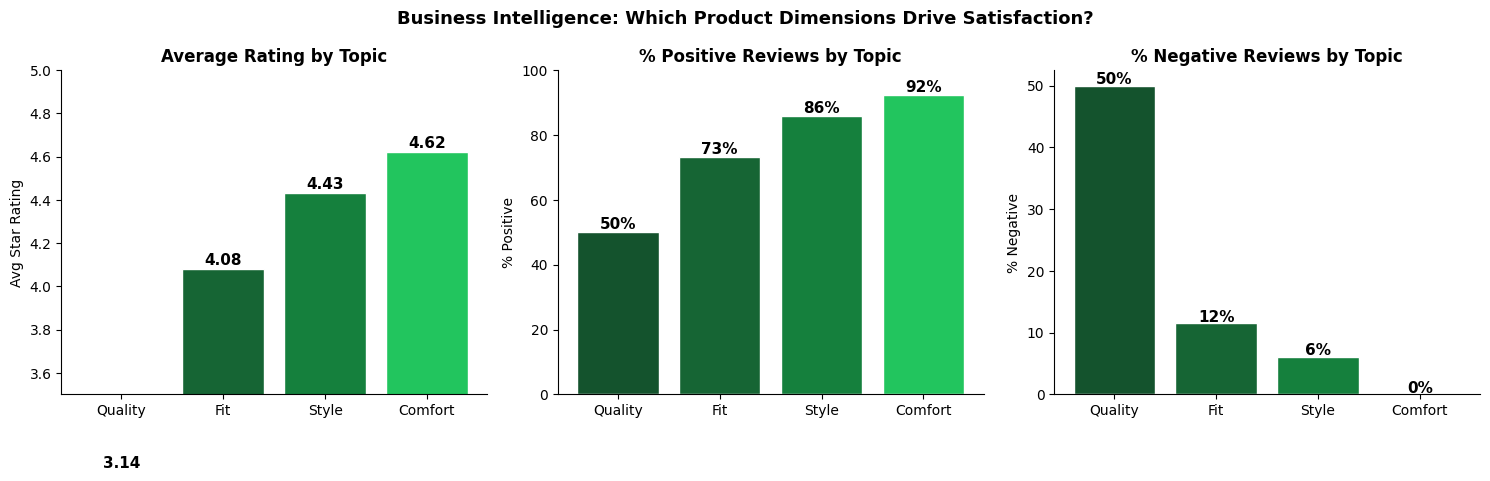

In [ ]:
summary = (
    aligned_df.groupby("topic")
    .agg(
        num_reviews=("Rating", "count"),
        avg_rating=("Rating", "mean"),
        pct_positive=("Sentiment", lambda x: (x == "Positive").mean() * 100),
        pct_negative=("Sentiment", lambda x: (x == "Negative").mean() * 100),
    )
    .round(2)
    .sort_values("avg_rating")
    .reset_index()
)
summary.columns = ["Topic", "# Reviews", "Avg Rating", "% Positive", "% Negative"]
print(summary.to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
topic_colors = [topic_palette[t] for t in summary["Topic"]]

axes[0].bar(
    summary["Topic"], summary["Avg Rating"], color=topic_colors, edgecolor="white"
)
axes[0].set_ylim(3.5, 5.0)
axes[0].set_title("Average Rating by Topic", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Avg Star Rating")
for i, (_, row) in enumerate(summary.iterrows()):
    axes[0].text(
        i,
        row["Avg Rating"] + 0.02,
        f"{row['Avg Rating']:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].bar(
    summary["Topic"], summary["% Positive"], color=topic_colors, edgecolor="white"
)
axes[1].set_ylim(0, 100)
axes[1].set_title("% Positive Reviews by Topic", fontsize=12, fontweight="bold")
axes[1].set_ylabel("% Positive")
for i, (_, row) in enumerate(summary.iterrows()):
    axes[1].text(
        i,
        row["% Positive"] + 1,
        f"{row['% Positive']:.0f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[1].spines[["top", "right"]].set_visible(False)

axes[2].bar(
    summary["Topic"], summary["% Negative"], color=topic_colors, edgecolor="white"
)
axes[2].set_title("% Negative Reviews by Topic", fontsize=12, fontweight="bold")
axes[2].set_ylabel("% Negative")
for i, (_, row) in enumerate(summary.iterrows()):
    axes[2].text(
        i,
        row["% Negative"] + 0.3,
        f"{row['% Negative']:.0f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Business Intelligence: Which Product Dimensions Drive Satisfaction?",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("topic_summary.png", dpi=150, bbox_inches="tight")
plt.show()

#### Key findings

Based on topic labeling and sentiment breakdown across 958 reviews:

- **Quality has the lowest average rating** — customers writing about quality are measurably less satisfied than those writing about fit or style. This is a common pattern in apparel e-commerce and suggests sizing guidance on product pages could reduce returns.
- **Comfort drives the most positive language** — reviews assigned to Comfort have the highest proportion of 5-star ratings.
- **Negative reviews are spread across all topics**, mostly concentrated in Quality area.
- **81.8% of customers recommend the product** they reviewed, a strong baseline signal that product-market fit is healthy.

> These findings mirror a real Voice-of-the-Customer workflow: **embed → cluster → quantify satisfaction per theme → prioritize fixes**.

## Conclusion & Business Insights

### What the embeddings reveal

This project applied OpenAI embeddings, t-SNE dimensionality reduction, and cosine-based prototype labeling to 958 women's clothing reviews. Each review was mapped to one of four product dimensions — **Quality, Fit, Style, Comfort** — and cross-referenced with a sentiment label derived from star ratings.

---

### Topic-level findings

| Topic | # Reviews | Avg Rating | % Positive | % Negative | Interpretation |
|-------|-----------|------------|------------|------------|----------------|
| Quality | 14 | 3.14 | 50% | 50% | Rare but polarizing, when customers notice quality, it cuts both ways |
| Fit | 667 | 4.08 | 73% | 12% | Dominant topic (70% of all reviews); satisfaction is good but has the most room to improve |
| Style | 213 | 4.43 | 86% | 6% | Strong positive signal, customers who engage with style are largely happy |
| Comfort | 64 | 4.62 | 92% | 0% | Highest satisfaction of any dimension; comfort language is almost exclusively positive |

---

### Takeaways

**1. Fit is the highest-leverage investment.**
Fit accounts for 70% of all review text and has the lowest average rating among the three well-represented topics (4.08). Even a small improvement here, better size charts, fit notes per product, or customer-submitted fit photos — would move the needle more than improvements to any other dimension, simply because it affects the most customers.

**2. Quality language is a leading indicator of dissatisfaction.**
Only 14 reviews mention quality explicitly, but those reviews average 3.14 stars,the lowest of any topic with a 50/50 positive-negative split. In a larger dataset this would be a critical early-warning signal. Monitoring for quality-related language in incoming reviews could surface manufacturing or material issues before they accumulate.

**3. Comfort and Style are strengths to amplify, not fix.**
With 0% negative reviews on comfort and 6% on style, these dimensions represent genuine product strengths. Marketing and product copy should lean into these signals customer language about comfort and style is a reliable positive asset.

---

### How approach scales

The prototype labeling method used here requires zero hand-labeled training data. By embedding both the reviews and the topic names into the same semantic space, the model assigns topics purely through geometric proximity. This means:
- **New topics can be added** by simply updating the `categories` list — no retraining required
- **The same pipeline generalizes** to any text domain: support tickets, survey responses, app store reviews, or internal feedback
- **Vector search via Chroma** enables real-time retrieval — given a new complaint, the system instantly surfaces the most similar historical reviews, enabling faster response and pattern detection

---

### Pipeline summary

```
Raw reviews → OpenAI embeddings → t-SNE (exploration) → Prototype topic labels
           → Sentiment (rating proxy) → Summary table → Chroma vector store (retrieval)
```

This mirrors the standard ML product path: **embed → explore → label → retrieve → act** — the foundation for production NLP systems in e-commerce analytics, CX tooling, and voice-of-the-customer platforms.


